### Project Setup: Mount Drive and Create Folder Structure

This cell initializes the project environment by mounting Google Drive to access and store project files. It then defines the base directory for `symAD-ECNN` and creates a comprehensive folder structure (`data`, `models`, `logs`, `results`) to organize raw data, processed data, model checkpoints, and results, ensuring a tidy and scalable project setup.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = "/content/drive/MyDrive/symAD-ECNN"
folders = [
    "data/raw_ixi",
    "data/processed_ixi",
    "notebooks",
    "models/baseline",
    "models/cnn",
    "models/ecnn",
    "logs",
    "results/reconstructions",
    "results/anomaly_maps"
]

for f in folders:
    os.makedirs(os.path.join(BASE, f), exist_ok=True)

print("Folder structure created successfully.")


Mounted at /content/drive
Folder structure created successfully.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Upload Kaggle API Credentials

This cell facilitates the secure upload of your `kaggle.json` file, which contains your Kaggle API authentication credentials. This step is crucial for programmatically interacting with Kaggle, such as downloading datasets, without manually logging in.  

(upload in side panel)

### Configure Kaggle API Credentials

After uploading `kaggle.json`, this cell moves the file to the correct directory (`~/.kaggle/`) and sets appropriate file permissions (`chmod 600`). This ensures that the Kaggle API client can find and securely use your credentials for subsequent operations like dataset downloads.

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


### Download and Unzip Preprocessed Dataset from Kaggle

This cell utilizes the Kaggle API to download the specified preprocessed brain MRI dataset directly into the `data/raw_ixi` directory of your project. The `--unzip` flag automatically extracts the contents, preparing the raw NIfTI files for further processing.

In [ ]:
!kaggle datasets download -d hamedamin/preprocessed-oasis-and-epilepsy-and-ixi -p "/content/drive/MyDrive/symAD-ECNN/data/raw_ixi" --unzip

Dataset URL: https://www.kaggle.com/datasets/hamedamin/preprocessed-oasis-and-epilepsy-and-ixi
License(s): CC-BY-SA-3.0
 99% 4.19G/4.21G [00:29<00:00, 184MB/s]
100% 4.21G/4.21G [00:29<00:00, 155MB/s]


### Verify Raw Data Contents

This cell lists the contents of the `data/raw_ixi` directory using the `ls` command. This step is important to confirm that the dataset has been downloaded and extracted successfully, and to get an overview of the initial file structure.

In [2]:
!ls "/content/drive/MyDrive/symAD-ECNN/data/raw_ixi"

a.rar  mri_IXI_480_2  mr_IXI_480i


### Initial NIfTI File Integrity Check

This cell performs an initial check of the NIfTI files in the `data/raw_ixi` directory. It iterates through all files, attempts to load `.nii` or `.nii.gz` files using `nibabel`, and reports any files that cannot be loaded due to corruption. It also provides a count of all valid NIfTI files found.

In [3]:
import nibabel as nib
import os

RAW = "/content/drive/MyDrive/symAD-ECNN/data/raw_ixi"

count = 0
for root, dirs, files in os.walk(RAW):
    for f in files:
        if f.endswith(".nii") or f.endswith(".nii.gz"):
            try:
                _ = nib.load(os.path.join(root, f))
            except:
                print("Corrupted:", f)
            count += 1

print("Total NIfTI files:", count)


Corrupted: wj_IXI117-Guys-0763-T1.nii
Corrupted: wj_IXI118-Guys-0764-T1.nii
Corrupted: wj_IXI119-Guys-0765-T1.nii
Corrupted: wj_IXI120-Guys-0766-T1.nii
Corrupted: wj_IXI121-Guys-0772-T1.nii
Corrupted: wj_IXI122-Guys-0773-T1.nii
Corrupted: wj_IXI123-Guys-0774-T1.nii
Corrupted: wj_IXI126-HH-1437-T1.nii
Corrupted: wj_IXI127-HH-1451-T1.nii
Corrupted: wj_IXI128-HH-1470-T1.nii
Corrupted: wj_IXI129-Guys-0775-T1.nii
Corrupted: wj_IXI130-HH-1528-T1.nii
Corrupted: wj_IXI131-HH-1527-T1.nii
Corrupted: wj_IXI132-HH-1415-T1.nii
Corrupted: wj_IXI134-Guys-0780-T1.nii
Corrupted: wj_IXI135-Guys-0779-T1.nii
Corrupted: wj_IXI136-HH-1452-T1.nii
Corrupted: wj_IXI137-HH-1472-T1.nii
Corrupted: wj_IXI138-Guys-0746-T1.nii
Corrupted: wj_IXI139-Guys-0815-T1.nii
Corrupted: wj_IXI140-Guys-0787-T1.nii
Corrupted: wj_IXI141-Guys-0789-T1.nii
Corrupted: wj_IXI142-Guys-0786-T1.nii
Corrupted: wj_IXI143-Guys-0785-T1.nii
Corrupted: wj_IXI144-Guys-0788-T1.nii
Corrupted: wj_IXI145-Guys-0781-T1.nii
Corrupted: wj_IXI146-HH-1389

### Visualize a Sample Raw MRI Slice

This cell demonstrates how to load a single sample NIfTI file (specifically a Grey Matter (GM) map, indicated by `mwp1`) and visualize one of its central 2D slices using `matplotlib`. This provides a visual inspection of the raw, preprocessed MRI data before further processing.

Loaded sample: /content/drive/MyDrive/symAD-ECNN/data/raw_ixi/mr_IXI_480i/mwp1IXI115-Guys-0738-T1.nii


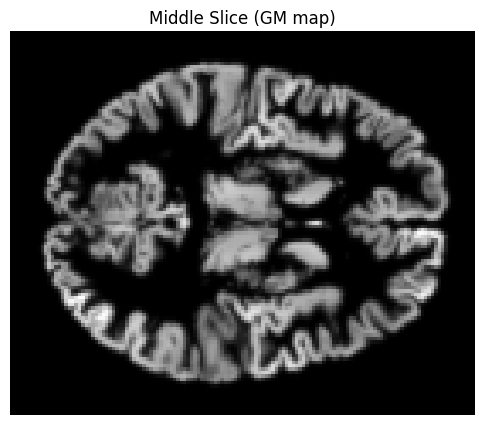

In [4]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import glob

sample = glob.glob("/content/drive/MyDrive/symAD-ECNN/data/raw_ixi/**/*mwp1*.nii", recursive=True)[0]
print("Loaded sample:", sample)

vol = nib.load(sample).get_fdata()
mid = vol.shape[2] // 2

plt.figure(figsize=(6,6))
plt.imshow(vol[:,:,mid], cmap='gray')
plt.title("Middle Slice (GM map)")
plt.axis('off')
plt.show()


### Process 3D NIfTI Volumes into Normalized 2D Slices

This crucial cell iterates through the raw NIfTI GM maps, extracts each 2D slice, normalizes its pixel values to a 0-1 range, and saves it as both a NumPy array (`.npy`) and a PNG image in the `data/processed_ixi` directory. It includes error handling to skip corrupted NIfTI files and omits empty slices, preparing a standardized 2D dataset for model training.

In [ ]:
import nibabel as nib
import numpy as np
import os
from tqdm import tqdm
import cv2

RAW = "/content/drive/MyDrive/symAD-ECNN/data/raw_ixi"
OUT = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi"
os.makedirs(OUT, exist_ok=True)

def normalize(x):
    x = x.astype(np.float32)
    if x.max() - x.min() < 1e-6:
        return np.zeros_like(x)
    return (x - x.min()) / (x.max() - x.min())

idx = 0
bad_files = []

for root, _, files in os.walk(RAW):
    for f in files:
        if "mwp1" in f and f.endswith(".nii"):  # GM maps
            full_path = os.path.join(root, f)

            try:
                vol = nib.load(full_path).get_fdata()
            except Exception as e:
                print("❌ Skipping corrupted file:", f)
                bad_files.append(f)
                continue

            Z = vol.shape[2]
            for s in range(Z):
                slice_ = vol[:,:,s]

                # skip empty slices
                if np.count_nonzero(slice_) / slice_.size < 0.12:
                    continue

                norm = normalize(slice_)
                np.save(f"{OUT}/slice_{idx:06d}.npy", norm)

                # also save as PNG preview
                png = (norm * 255).astype(np.uint8)
                cv2.imwrite(f"{OUT}/slice_{idx:06d}.png", png)

                idx += 1

print("Total valid slices:", idx)
print("Total corrupted files skipped:", len(bad_files))


❌ Skipping corrupted file: mwp1IXI314-IOP-0889-SAGFSPGR_-sIXI31_-0003-00001-000001-01.nii
❌ Skipping corrupted file: mwp1IXI316-HH-1862-MADisoTFE1_-s3T176_-0301-00003-000001-01.nii
❌ Skipping corrupted file: mwp1IXI322-IOP-0891-SAGFSPGR_-sIXI32_-0003-00001-000001-01.nii
❌ Skipping corrupted file: mwp1IXI327-HH-1999-MADisoTFE1_-s3T190_-0301-00003-000001-01.nii
❌ Skipping corrupted file: mwp1IXI334-HH-1907-MADisoTFE1_-s3T180_-0301-00003-000001-01.nii
❌ Skipping corrupted file: mwp1IXI344-Guys-0905-MPRAGESEN_-s306_-0301-00003-000001-01.nii
❌ Skipping corrupted file: mwp1IXI369-Guys-0924-MPRAGESEN_-s402_-0301-00003-000001-01.nii
❌ Skipping corrupted file: mwp1IXI378-IOP-0972-SAGFSPGR_-sIXI37_-0003-00001-000001-01.nii
❌ Skipping corrupted file: mwp1IXI388-IOP-0973-SAGFSPGR_-sIXI38_-0003-00001-000001-01.nii
❌ Skipping corrupted file: mwp1IXI396-HH-2115-MADisoTFE1_-s3T203_-0301-00003-000001-01.nii
❌ Skipping corrupted file: mwp1IXI399-Guys-0966-MPRAGESEN_-s413_-0301-00003-000001-01.nii
❌ Skip

### Display Project Directory Structure and File Counts

This cell provides an overview of your project's directory structure within Google Drive, listing each folder and the number of files it contains. This helps in understanding the organization and distribution of files across your project.

In [5]:
import os
for root, dirs, files in os.walk("/content/drive/MyDrive/symAD-ECNN", topdown=True):
    print(root, len(files))


/content/drive/MyDrive/symAD-ECNN 0
/content/drive/MyDrive/symAD-ECNN/notebooks 2
/content/drive/MyDrive/symAD-ECNN/data 0
/content/drive/MyDrive/symAD-ECNN/data/raw_ixi 1
/content/drive/MyDrive/symAD-ECNN/data/raw_ixi/mr_IXI_480i 773
/content/drive/MyDrive/symAD-ECNN/data/raw_ixi/mri_IXI_480_2 796
/content/drive/MyDrive/symAD-ECNN/models 0
/content/drive/MyDrive/symAD-ECNN/models/baseline 0
/content/drive/MyDrive/symAD-ECNN/models/cnn 0
/content/drive/MyDrive/symAD-ECNN/models/ecnn 0
/content/drive/MyDrive/symAD-ECNN/logs 0
/content/drive/MyDrive/symAD-ECNN/results 0
/content/drive/MyDrive/symAD-ECNN/results/reconstructions 0
/content/drive/MyDrive/symAD-ECNN/results/anomaly_maps 0


### Inspect First 30 Processed Files

This cell lists the names of the first 30 files generated in the `data/processed_ixi` directory. This serves as a quick check to ensure that the slice extraction and saving process successfully created the expected `.npy` and `.png` files.

In [ ]:
import os

path = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi"
files = os.listdir(path)[:30]

files

['slice_023575.png',
 'slice_023555.png',
 'slice_023553.npy',
 'slice_023587.png',
 'slice_023558.png',
 'slice_023560.png',
 'slice_023592.npy',
 'slice_023586.png',
 'slice_023583.npy',
 'slice_023583.png',
 'slice_023584.npy',
 'slice_023578.png',
 'slice_023580.npy',
 'slice_023556.npy',
 'slice_023557.npy',
 'slice_023569.npy',
 'slice_023572.npy',
 'slice_023560.npy',
 'slice_023593.png',
 'slice_023591.png',
 'slice_023551.png',
 'slice_023582.npy',
 'slice_023577.npy',
 'slice_023566.png',
 'slice_023556.png',
 'slice_023559.png',
 'slice_023576.png',
 'slice_023578.npy',
 'slice_023571.png',
 'slice_023575.npy']

### Load and Inspect a Sample Processed Slice

This cell loads one of the `.npy` files from the `data/processed_ixi` directory (a single 2D slice) to inspect its properties. It confirms the shape, minimum, and maximum pixel values, verifying that the normalization step was correctly applied and the data is in the expected format for model input.

In [6]:
import numpy as np
import os

path = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi"

# Find first .npy slice
sample_file = [f for f in os.listdir(path) if f.endswith(".npy")][0]
sample_path = os.path.join(path, sample_file)
sample = np.load(sample_path)

print("Sample file:", sample_file)
print("Shape:", sample.shape)
print("Min:", sample.min(), "Max:", sample.max())


Sample file: slice_003094.npy
Shape: (113, 137)
Min: 0.0 Max: 1.0


### Data Preparation: Resize, Split, and DataLoader Setup

This cell is designed for further data preparation. It resizes all processed 2D slices to a uniform `128x128` dimension, splits the dataset into training and validation sets, and then sets up PyTorch `Dataset` and `DataLoader` objects. These are essential for efficient batch-wise data loading and augmentation during model training.

In [ ]:
# # ===========================================
# # FYP Data Preparation: Resize + Split + DataLoader
# # ===========================================

# import numpy as np
# import os
# from skimage.transform import resize
# from sklearn.model_selection import train_test_split
# from tqdm import tqdm
# import torch
# from torch.utils.data import Dataset, DataLoader

# # -------------------------------
# # Paths
# # -------------------------------
# base_path = "/content/drive/MyDrive/symAD-ECNN"
# input_path = os.path.join(base_path, "data/processed")
# resized_path = os.path.join(base_path, "data/processed/resized")
# os.makedirs(resized_path, exist_ok=True)

# # -------------------------------
# # 1. Resize slices to 128x128
# # -------------------------------
# files = sorted([f for f in os.listdir(input_path) if f.endswith(".npy")])

# print(f"Resizing {len(files)} slices to 128x128...")
# for f in tqdm(files):
#     slice_array = np.load(os.path.join(input_path, f))
#     resized = resize(slice_array, (128,128), mode='reflect', anti_aliasing=True)
#     np.save(os.path.join(resized_path, f), resized)

# # -------------------------------
# # 2. Train / Validation split
# # -------------------------------
# all_files = sorted([f for f in os.listdir(resized_path) if f.endswith(".npy")])
# train_files, val_files = train_test_split(all_files, test_size=0.05, random_state=42)

# # Optional: save the lists for future use
# np.save(os.path.join(base_path, "data/processed/train_files.npy"), train_files)
# np.save(os.path.join(base_path, "data/processed/val_files.npy"), val_files)

# print(f"Train slices: {len(train_files)} | Validation slices: {len(val_files)}")

# # -------------------------------
# # 3. PyTorch Dataset
# # -------------------------------
# class MRISlicesDataset(Dataset):
#     def __init__(self, file_list, folder_path, transform=None):
#         self.file_list = file_list
#         self.folder_path = folder_path
#         self.transform = transform

#     def __len__(self):
#         return len(self.file_list)

#     def __getitem__(self, idx):
#         img = np.load(os.path.join(self.folder_path, self.file_list[idx]))
#         img = np.expand_dims(img, axis=0)  # channel dimension for CNN
#         if self.transform:
#             img = self.transform(img)
#         return torch.tensor(img, dtype=torch.float32)

# # -------------------------------
# # 4. DataLoaders
# # -------------------------------
# batch_size = 32

# train_dataset = MRISlicesDataset(train_files, resized_path)
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# val_dataset = MRISlicesDataset(val_files, resized_path)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# print("DataLoaders ready. You can now start training!")
# print(f"Train batches: {len(train_loader)} | Validation batches: {len(val_loader)}")


Resizing 34967 slices to 128x128...


100%|██████████| 34967/34967 [25:59<00:00, 22.42it/s]


Train slices: 33218 | Validation slices: 1749
DataLoaders ready. You can now start training!
Train batches: 1039 | Validation batches: 55


### Filter and Persist 2D Slices

This cell filters the previously processed 2D MRI slices (`.npy` files) based on a mean pixel value threshold (0.1). Slices with a mean pixel value below this threshold are considered 'empty' or low-information and are discarded. The filtered slices are then saved to a new directory `/content/drive/MyDrive/symAD-ECNN/data/processed/filtered_ixi`. This step ensures that only relevant data is used for subsequent model training, improving efficiency and model performance. The updated code also includes a check to skip files that have already been processed and saved, making the filtering process resumable if interrupted.

In [ ]:
import numpy as np
import os
from tqdm import tqdm

base_path = "/content/drive/MyDrive/symAD-ECNN"
input_path = os.path.join(base_path, "data/processed_ixi")
filtered_path = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi/filtered_ixi"
os.makedirs(filtered_path, exist_ok=True)

files = sorted([f for f in os.listdir(input_path) if f.endswith(".npy")])

kept = 0
for f in tqdm(files, desc="Filtering slices"): # Added tqdm for progress tracking
    output_file_path = os.path.join(filtered_path, f)
    # Skip if the filtered file already exists
    if os.path.exists(output_file_path):
        kept += 1
        continue

    arr = np.load(os.path.join(input_path, f))
    if arr.mean() > 0.1:   # discard empty slices
        np.save(output_file_path, arr)
        kept += 1

print(f"Filtered slices kept: {kept}")

Filtered slices kept: 16771


Visulaise the filtered slices.

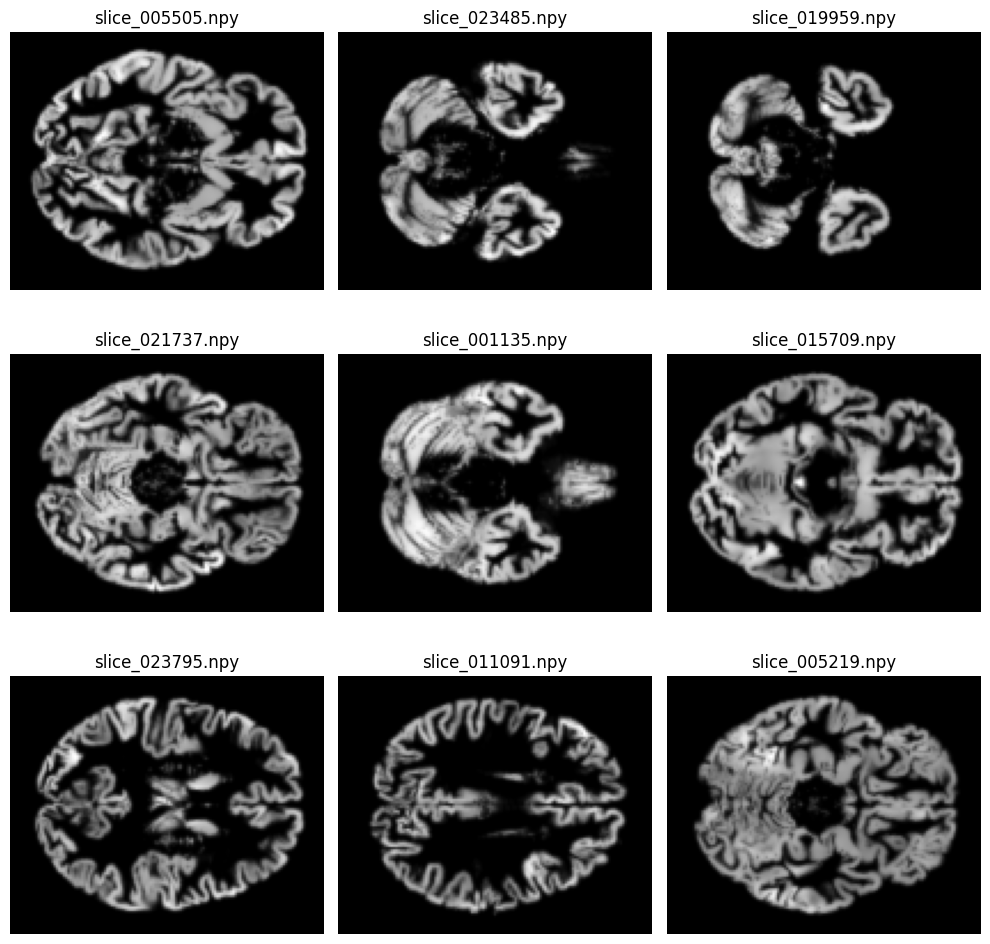

In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
import random

filtered_path = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi/filtered_ixi"

# list filtered files
files = sorted([f for f in os.listdir(filtered_path) if f.endswith(".npy")])

# choose random 9 slices
sample_files = random.sample(files, 9)

plt.figure(figsize=(10, 10))

for i, f in enumerate(sample_files):
    img = np.load(os.path.join(filtered_path, f))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
import os
filtered_path = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi/filtered_ixi"
print("Number of slices in filtered folder:", len(os.listdir(filtered_path)))

Number of slices in filtered folder: 16771


Resizing slices to standard 128 x 128

In [ ]:
import numpy as np
import os
from tqdm import tqdm
from skimage.transform import resize

# Paths
base_path = "/content/drive/MyDrive/symAD-ECNN"
filtered_path = os.path.join(base_path, "data/processed_ixi/filtered_ixi")
resized_path = os.path.join(base_path, "data/processed_ixi/resized_ixi")

os.makedirs(resized_path, exist_ok=True)

# Get all filtered slices
files = sorted([f for f in os.listdir(filtered_path) if f.endswith(".npy")])

batch_size = 500  # safe batch size
total = len(files)

print(f"Total filtered slices: {total}")
print("Starting batch-wise resizing...\n")

for i in range(0, total, batch_size):
    batch_files = files[i : i + batch_size]

    print(f"Processing batch {i//batch_size + 1} ...")

    for f in tqdm(batch_files):
        src_path = os.path.join(filtered_path, f)
        dst_path = os.path.join(resized_path, f)

        # Skip if already resized
        if os.path.exists(dst_path):
            continue

        try:
            arr = np.load(src_path)
            resized = resize(arr, (128, 128), mode="reflect", anti_aliasing=True)
            np.save(dst_path, resized)
        except:
            print("Error resizing:", f)
            continue

print("\n🎉 Done! Safely resized images saved in /resized_ixi")


Total filtered slices: 16771
Starting batch-wise resizing...

Processing batch 1 ...


100%|██████████| 500/500 [10:44<00:00,  1.29s/it]


Processing batch 2 ...


100%|██████████| 500/500 [00:12<00:00, 40.00it/s]


Processing batch 3 ...


...

Processing batch 33 ...


100%|██████████| 500/500 [00:11<00:00, 42.46it/s]


Processing batch 34 ...


100%|██████████| 271/271 [00:06<00:00, 42.03it/s]


🎉 Done! Safely resized images saved in /resized


In [9]:
import os
resized_path = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi/resized_ixi"
print("Number of slices in resized folder:", len(os.listdir(resized_path)))

Number of slices in resized folder: 16771


In [10]:
import numpy as np
import os

resized_path = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi/resized_ixi"

# pick any one sample (first file)
sample_file = sorted([f for f in os.listdir(resized_path) if f.endswith(".npy")])[0]
sample = np.load(os.path.join(resized_path, sample_file))

print("File:", sample_file)
print("Shape:", sample.shape)
print("Min pixel value:", sample.min())
print("Max pixel value:", sample.max())
print("Mean pixel value:", sample.mean())

File: slice_000017.npy
Shape: (128, 128)
Min pixel value: 0.0
Max pixel value: 0.98004687
Mean pixel value: 0.10454521


---

## Step 8: Split Data into Train/Val (90/10)

Now that preprocessing is complete, let's split the data into training (90%) and validation (10%) sets.

This is the **final step** before training!

In [ ]:
import random
import shutil
from pathlib import Path

# Configuration
RESIZED_FOLDER = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi/resized_ixi"
TRAIN_FOLDER = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi/train"
VAL_FOLDER = "/content/drive/MyDrive/symAD-ECNN/data/processed_ixi/val"
TRAIN_RATIO = 0.9  # 90% train, 10% validation

print("="*60)
print("IXI DATA TRAIN/VAL SPLIT")
print("="*60)
print(f"\nConfiguration:")
print(f"  Source: {RESIZED_FOLDER}")
print(f"  Train destination: {TRAIN_FOLDER}")
print(f"  Val destination: {VAL_FOLDER}")
print(f"  Split ratio: {int(TRAIN_RATIO*100)}% train / {int((1-TRAIN_RATIO)*100)}% val")

### Create Train/Val Directories

In [ ]:
# Create directories
os.makedirs(TRAIN_FOLDER, exist_ok=True)
os.makedirs(VAL_FOLDER, exist_ok=True)

print(f"\n✓ Created train folder: {TRAIN_FOLDER}")
print(f"✓ Created val folder: {VAL_FOLDER}")

### Get All Files and Calculate Split

In [ ]:
# Get all .npy files
all_files = [f for f in os.listdir(RESIZED_FOLDER) if f.endswith('.npy')]
total_files = len(all_files)

print(f"\n✓ Found {total_files:,} .npy files")

# Shuffle files randomly (with fixed seed for reproducibility)
random.seed(42)
random.shuffle(all_files)

# Calculate split index
split_idx = int(total_files * TRAIN_RATIO)

# Split into train and val
train_files = all_files[:split_idx]
val_files = all_files[split_idx:]

print(f"\nSplit calculated:")
print(f"  Train: {len(train_files):,} files ({len(train_files)/total_files*100:.1f}%)")
print(f"  Val: {len(val_files):,} files ({len(val_files)/total_files*100:.1f}%)")
print(f"  Total: {len(train_files) + len(val_files):,} files")

### Copy Files to Train Folder

This will take 5-10 minutes. Progress updates every 1000 files.

In [ ]:
print(f"\nCopying {len(train_files):,} files to train folder...")
print("(Progress updates every 1000 files)\n")

for i, filename in enumerate(train_files):
    src = os.path.join(RESIZED_FOLDER, filename)
    dst = os.path.join(TRAIN_FOLDER, filename)
    shutil.copy2(src, dst)
    
    if (i + 1) % 1000 == 0:
        progress = (i + 1) / len(train_files) * 100
        print(f"  Progress: {i + 1:,}/{len(train_files):,} ({progress:.1f}%)")

print(f"\n✅ Completed! {len(train_files):,} files copied to train folder")

### Copy Files to Validation Folder

In [ ]:
print(f"\nCopying {len(val_files):,} files to validation folder...")
print("(Progress updates every 100 files)\n")

for i, filename in enumerate(val_files):
    src = os.path.join(RESIZED_FOLDER, filename)
    dst = os.path.join(VAL_FOLDER, filename)
    shutil.copy2(src, dst)
    
    if (i + 1) % 100 == 0:
        progress = (i + 1) / len(val_files) * 100
        print(f"  Progress: {i + 1:,}/{len(val_files):,} ({progress:.1f}%)")

print(f"\n✅ Completed! {len(val_files):,} files copied to validation folder")

### Verify Split

In [ ]:
print("\n" + "="*60)
print("VERIFICATION")
print("="*60 + "\n")

# Count files in each folder
train_count = len([f for f in os.listdir(TRAIN_FOLDER) if f.endswith('.npy')])
val_count = len([f for f in os.listdir(VAL_FOLDER) if f.endswith('.npy')])
total_split = train_count + val_count

print(f"Files in train folder: {train_count:,}")
print(f"Files in val folder: {val_count:,}")
print(f"Total after split: {total_split:,}")
print(f"Original total: {total_files:,}")

# Check if numbers match
if total_split == total_files:
    print("\n✅ SUCCESS! All files accounted for.")
else:
    print(f"\n⚠️ WARNING: File count mismatch!")
    print(f"  Expected: {total_files:,}")
    print(f"  Got: {total_split:,}")
    print(f"  Difference: {abs(total_split - total_files):,}")

### Sample Check

In [ ]:
print("\n" + "="*60)
print("SAMPLE CHECK")
print("="*60 + "\n")

try:
    # Load train sample
    train_sample_file = os.path.join(TRAIN_FOLDER, os.listdir(TRAIN_FOLDER)[0])
    train_sample = np.load(train_sample_file)
    print(f"✓ Train sample loaded")
    print(f"  Shape: {train_sample.shape}")
    print(f"  Dtype: {train_sample.dtype}")
    print(f"  Range: [{train_sample.min():.3f}, {train_sample.max():.3f}]")
    
    # Load val sample
    val_sample_file = os.path.join(VAL_FOLDER, os.listdir(VAL_FOLDER)[0])
    val_sample = np.load(val_sample_file)
    print(f"\n✓ Val sample loaded")
    print(f"  Shape: {val_sample.shape}")
    print(f"  Dtype: {val_sample.dtype}")
    print(f"  Range: [{val_sample.min():.3f}, {val_sample.max():.3f}]")
    
    print("\n✅ All samples loaded successfully!")
    
except Exception as e:
    print(f"❌ ERROR loading samples: {e}")

### Final Summary

In [ ]:
print("\n" + "="*60)
print("✅ PREPROCESSING COMPLETE!")
print("="*60 + "\n")

print(f"Training set: {train_count:,} samples ({train_count/total_files*100:.1f}%)")
print(f"Validation set: {val_count:,} samples ({val_count/total_files*100:.1f}%)")

print(f"\nData locations:")
print(f"  Train: {TRAIN_FOLDER}")
print(f"  Val: {VAL_FOLDER}")

print("\n" + "="*60)
print("NEXT STEPS")
print("="*60 + "\n")

print("1. Upload BraTS data to Drive (if not already done)")
print("2. Use these paths in your training notebooks:")
print(f"   IXI_TRAIN_PATH = '{TRAIN_FOLDER}'")
print(f"   IXI_VAL_PATH = '{VAL_FOLDER}'")
print("\n3. Start training your models:")
print("   - 01_baseline_autoencoder.ipynb")
print("   - 02_cnn_autoencoder.ipynb")
print("   - 03_ecnn_autoencoder.ipynb")

print("\n✅ Ready to train!")

### (Optional) Clean Up Original Folder

**Only run this if you want to save space and delete the original `resized_ixi` folder.**

⚠️ **WARNING**: This will permanently delete the source folder! Make sure train/val split completed successfully first.

In [ ]:
# Uncomment the lines below ONLY if you want to delete the original folder

# import shutil
# print(f"Deleting {RESIZED_FOLDER}...")
# shutil.rmtree(RESIZED_FOLDER)
# print("✓ Original folder deleted. Train/val folders remain.")
# print("\nThis saves ~2GB of storage space.")